# Customer Churn Prediction — EDA, Model Training & Interview Prep

## 1. Project Title & Objective

**Project:** Customer Churn Prediction System

This is a Machine Learning solution designed to **predict whether a telecom customer
will churn (leave the company)**, using customer account and service-usage features
(contract type, tenure, billing, internet/phone add-ons, etc.). The objective is to help
the business identify at-risk customers early and act on them before they leave.

> 🎤 **Interview soundbite:**
> *"The project I worked on is a Customer Churn Prediction System. It's a machine
> learning pipeline that predicts whether a telecom customer is likely to cancel their
> subscription, using their account and service usage data. The goal is to let the
> retention team proactively target high-risk customers instead of reacting after
> they've already left."*


## 2. Problem Statement & Motivation

Telecom companies lose recurring revenue every time a customer churns, and acquiring a
new customer is far more expensive than retaining an existing one. Manually reviewing
every account for churn risk doesn't scale, and simple rule-based flags (e.g. "customer
hasn't paid on time") miss most of the real signal.


## 3. Dataset & Technology Stack

- **Source:** Telco Customer Churn dataset (public, IBM sample dataset)
- **Rows:** ~7,043 customers
- **Columns:** 21 (20 features + `customerID`), target = `Churn` (Yes/No)
- **Tech stack:** Python, pandas, numpy, scikit-learn, matplotlib, seaborn, Flask,
  Streamlit, joblib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 4. Data Preprocessing & Exploratory Data Analysis (EDA)

### 4.1 Data Cleaning — duplicates & missing values


In [3]:
# --- Duplicate records ---
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows — nothing to remove.")


Duplicate rows found: 0
No duplicate rows — nothing to remove.


In [4]:
# --- Missing values ---
print("Missing values per column (raw):")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None found in raw form.")

# TotalCharges is stored as text and has blank strings for new customers (tenure = 0)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("\nMissing TotalCharges after numeric conversion:", df["TotalCharges"].isnull().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
print("Missing TotalCharges after median imputation:", df["TotalCharges"].isnull().sum())


Missing values per column (raw):
None found in raw form.

Missing TotalCharges after numeric conversion: 11
Missing TotalCharges after median imputation: 0


### 4.2 Target variable: Churn distribution

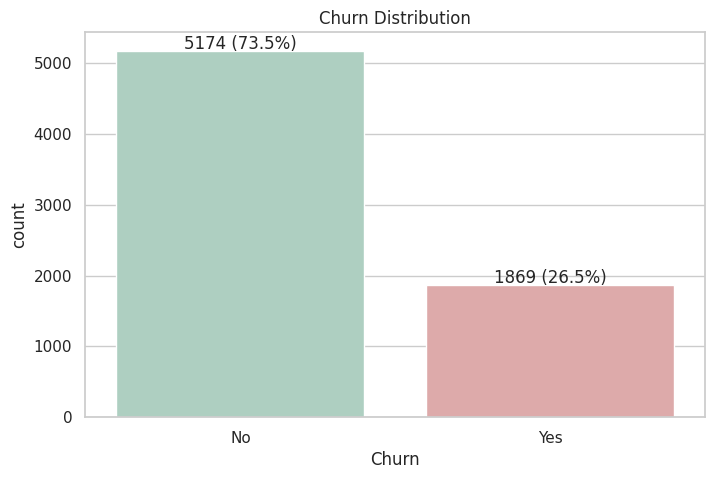

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
sns.countplot(data=df, x="Churn", hue="Churn", palette=["#a8d5c2", "#e6a1a1"], legend=False, ax=ax)
ax.set_title("Churn Distribution")
for i, v in enumerate(churn_counts):
    ax.text(i, v + 30, f"{v} ({churn_pct.iloc[i]:.1f}%)", ha="center")
plt.show()

churn_counts


The dataset is **moderately imbalanced**: ~73% of customers stay, ~27% churn. A
model that always predicted "No Churn" would already score ~73% accuracy, so precision/
recall on the churn class matter as much as overall accuracy (see Section 6).


### 4.3 Numeric features vs. churn

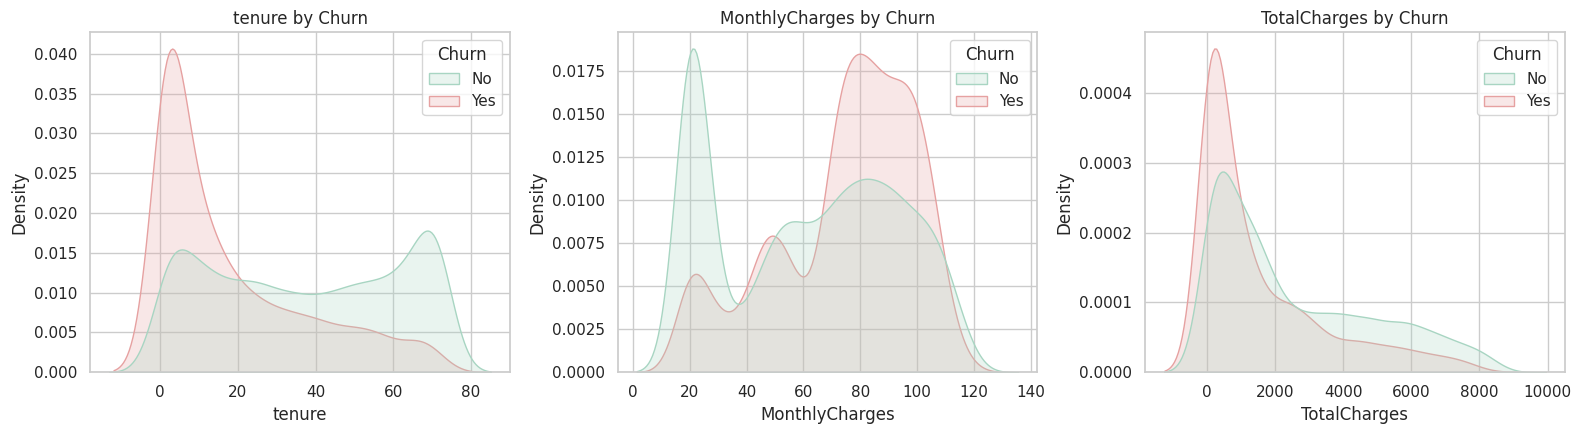

In [6]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", fill=True,
                palette=["#a8d5c2", "#e6a1a1"], common_norm=False, ax=ax)
    ax.set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()


**Observations:** customers with **low tenure** churn far more often; **higher
MonthlyCharges** correlates with higher churn; **TotalCharges** skews lower for churners
— mostly a byproduct of short tenure.

### 4.4 Outlier check (IQR method)

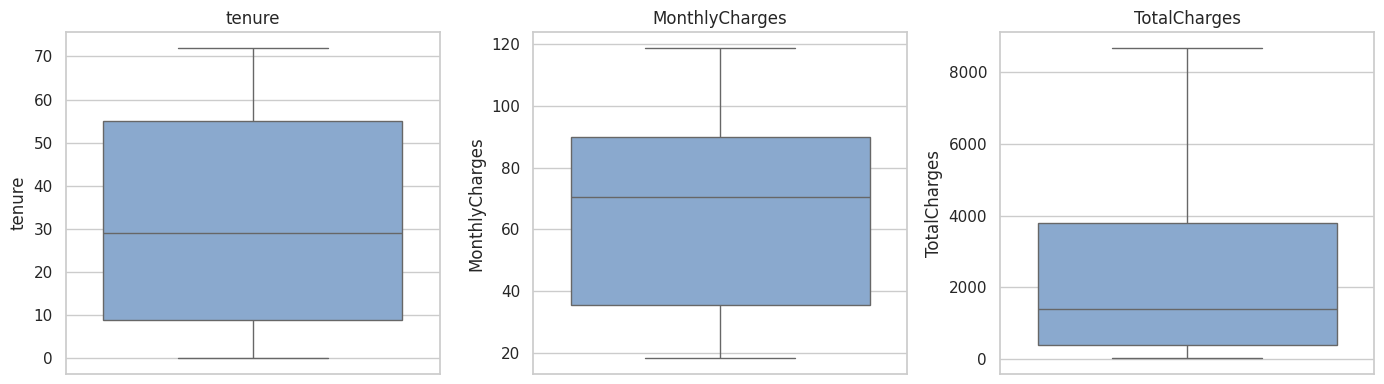

tenure: 0 outliers outside [-60.0, 124.0]
MonthlyCharges: 0 outliers outside [-46.0, 171.4]
TotalCharges: 0 outliers outside [-4674.3, 8863.2]


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, y=col, color="#7fa8d9", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers outside [{lower:.1f}, {upper:.1f}]")


### 4.5 Categorical features vs. churn

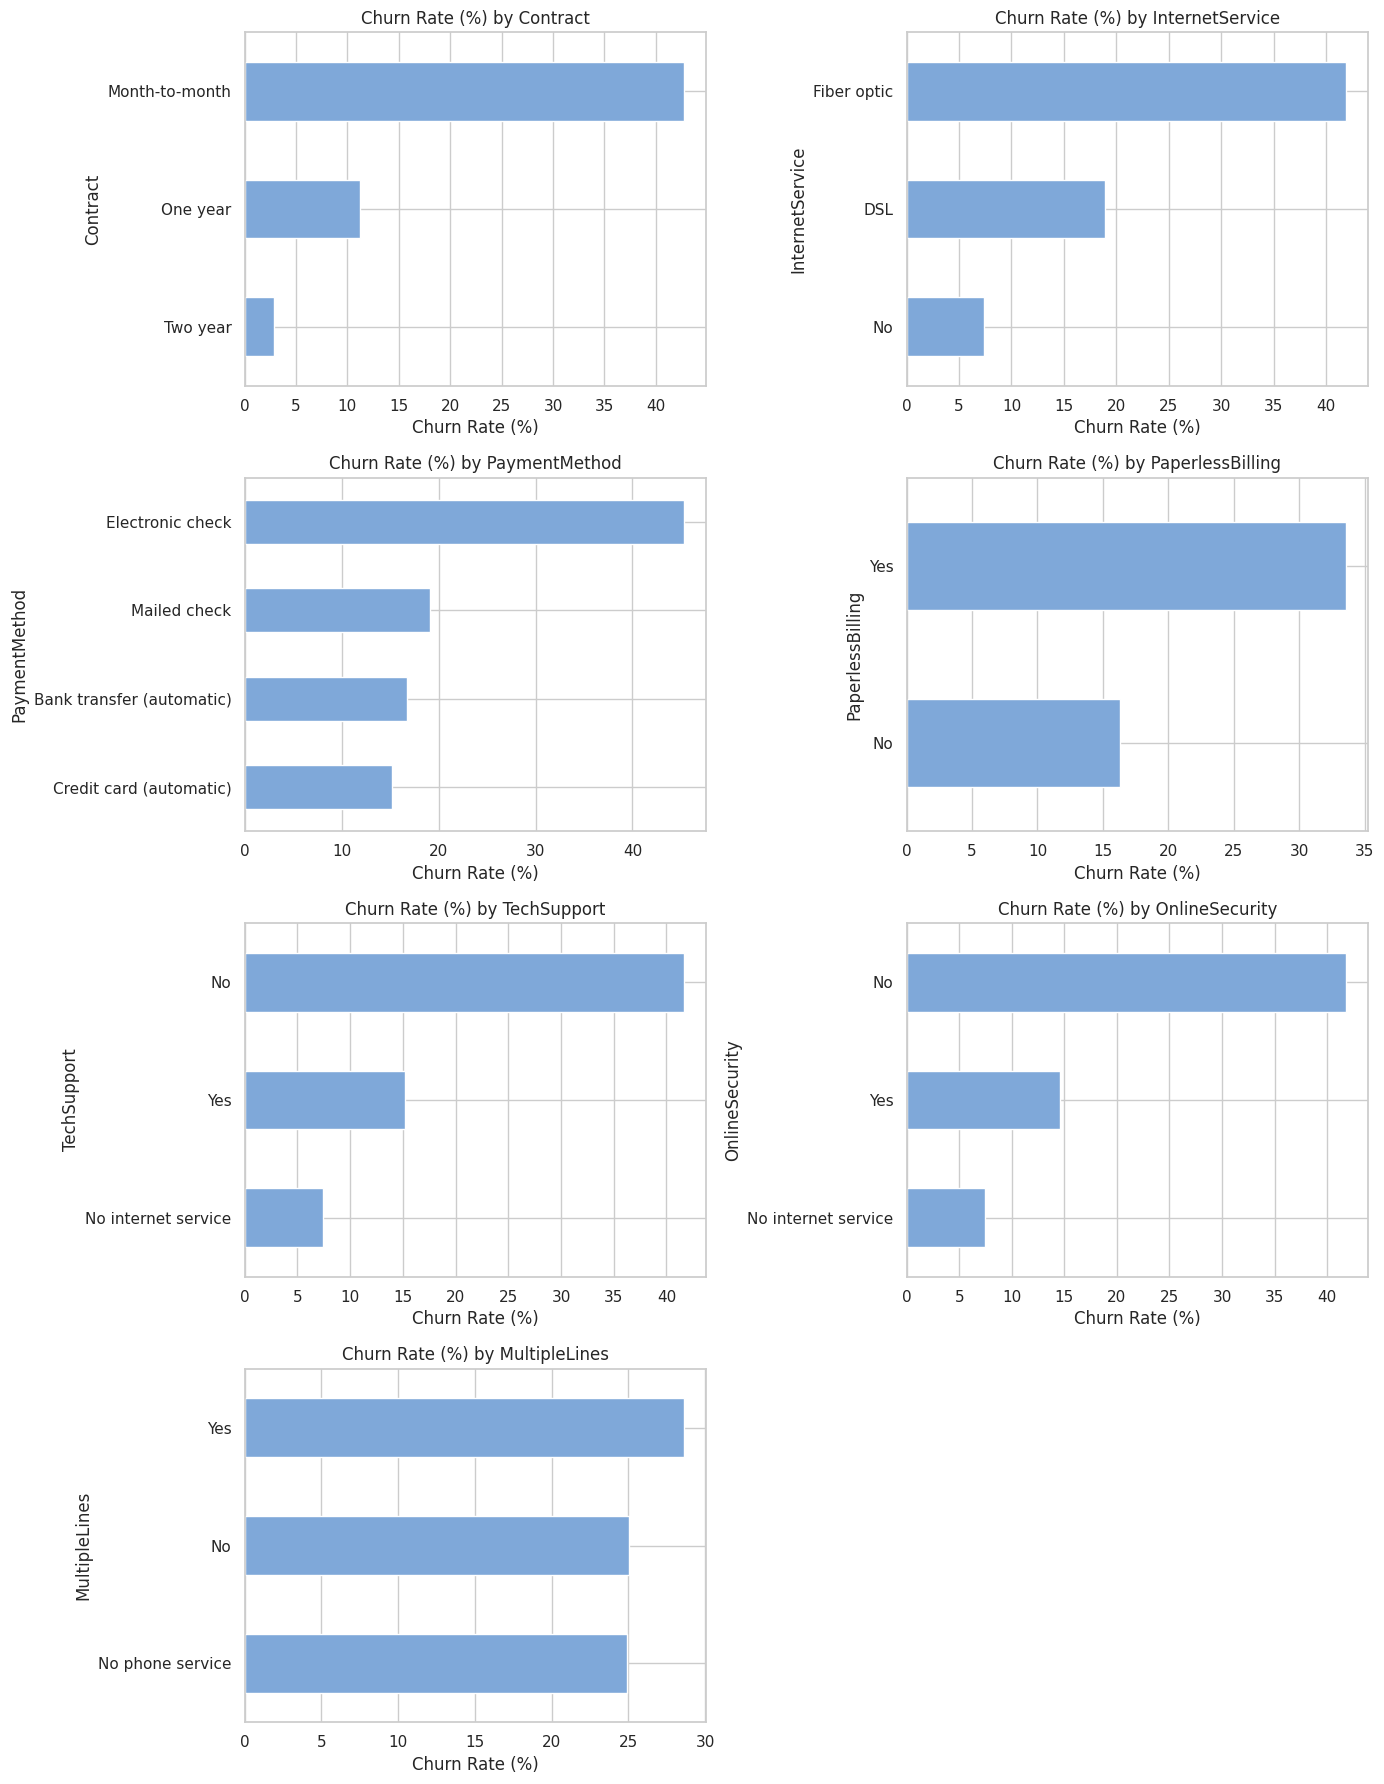

In [8]:
cat_cols_explore = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling",
                     "TechSupport", "OnlineSecurity", "MultipleLines"]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols_explore):
    churn_rate = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
    churn_rate.plot(kind="barh", ax=ax, color="#7fa8d9")
    ax.set_title(f"Churn Rate (%) by {col}")
    ax.set_xlabel("Churn Rate (%)")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Observations:** **Month-to-month contracts** churn far more than one/two-year
contracts; **Fiber optic** customers churn more than DSL/no-internet; **electronic
check** payers churn more than other payment methods; missing **online security / tech
support** correlates with higher churn.


### 4.6 Correlation among numeric features

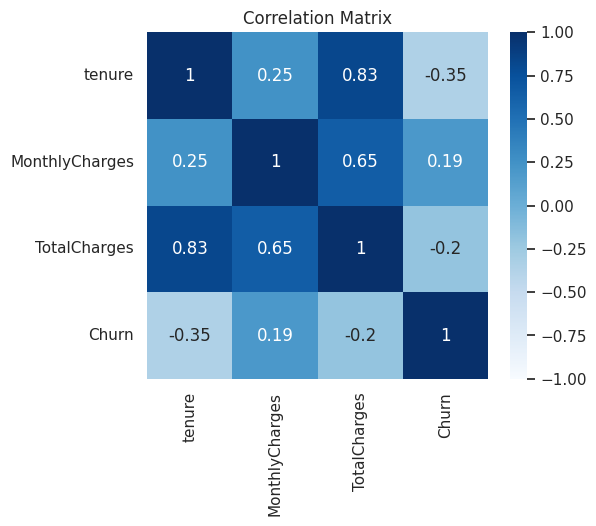

In [9]:
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
numeric_df["Churn"] = (df["Churn"] == "Yes").astype(int)

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix")
plt.show()


### 4.7 Feature Selection — reducing 19 features down to 10

The raw dataset has **19 usable features** (excluding `customerID`). Asking a user to
fill in 19 form fields on the front end is a lot of friction. To keep the web form short
**without hurting accuracy**, we rank features by importance using a quick Random Forest,
then keep only the strongest ones.


/tmp/ipykernel_578/3782684757.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_full = X_full.select_dtypes(include="object").columns.tolist()


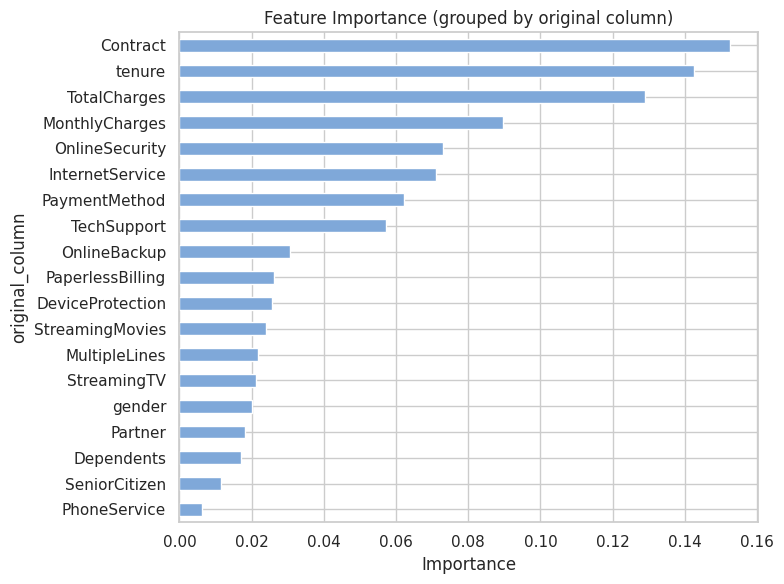

original_column
Contract            0.152524
tenure              0.142394
TotalCharges        0.128847
MonthlyCharges      0.089762
OnlineSecurity      0.073042
InternetService     0.071005
PaymentMethod       0.062342
TechSupport         0.057245
OnlineBackup        0.030765
PaperlessBilling    0.026245
DeviceProtection    0.025572
StreamingMovies     0.024041
MultipleLines       0.021815
StreamingTV         0.021216
gender              0.020107
Partner             0.018195
Dependents          0.017141
SeniorCitizen       0.011444
PhoneService        0.006295
Name: importance, dtype: float64

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

fi_df = df.drop(columns=["customerID"]).copy()
fi_df["Churn"] = fi_df["Churn"].map({"No": 0, "Yes": 1})

X_full = fi_df.drop(columns=["Churn"])
y_full = fi_df["Churn"]

cat_cols_full = X_full.select_dtypes(include="object").columns.tolist()
num_cols_full = [c for c in X_full.columns if c not in cat_cols_full]

fi_pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols_full),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_full),
])

Xt = fi_pre.fit_transform(X_full)
rf_fi = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
rf_fi.fit(Xt, y_full)

ohe = fi_pre.named_transformers_["cat"].named_steps["oh"]
cat_names = ohe.get_feature_names_out(cat_cols_full)
all_names = list(num_cols_full) + list(cat_names)

def original_column(feature_name):
    if feature_name in num_cols_full:
        return feature_name
    for c in cat_cols_full:
        if feature_name.startswith(c + "_"):
            return c
    return feature_name

imp_df = pd.DataFrame({"feature": all_names, "importance": rf_fi.feature_importances_})
imp_df["original_column"] = imp_df["feature"].apply(original_column)
grouped_importance = imp_df.groupby("original_column")["importance"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
grouped_importance.plot(kind="barh", ax=ax, color="#7fa8d9")
ax.invert_yaxis()
ax.set_title("Feature Importance (grouped by original column)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

grouped_importance


In [11]:
# Top 10 features by importance — this is the reduced set used for the
# front-end form in app.py / streamlit_app.py
FEATURES = [
    "tenure",
    "Contract",
    "MonthlyCharges",
    "TotalCharges",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling",
    "MultipleLines",
]
print(f"Reduced from {len(X_full.columns)} features down to {len(FEATURES)} features:")
FEATURES


Reduced from 19 features down to 10 features:


['tenure',
 'Contract',
 'MonthlyCharges',
 'TotalCharges',
 'InternetService',
 'OnlineSecurity',
 'TechSupport',
 'PaymentMethod',
 'PaperlessBilling',
 'MultipleLines']

## 5. Model Selection & Hyperparameter Tuning

Since this is a binary classification problem, we compare several algorithms:
**Logistic Regression**, **Random Forest**, and **Gradient Boosting** — all trained on
the reduced 10-feature set above.



In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

model_df = df.drop(columns=["customerID"]).copy()
model_df["Churn"] = model_df["Churn"].map({"No": 0, "Yes": 1})

X = model_df[FEATURES]
y = model_df["Churn"]

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in FEATURES if c not in num_cols]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (5634, 10)  Test shape: (1409, 10)


In [13]:
candidate_models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, C=1.0, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42
    ),
}

results = []
fitted_pipes = {}

for name, model in candidate_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    results.append({"Model": name, "Accuracy": round(acc, 4), "ROC_AUC": round(auc, 4)})
    fitted_pipes[name] = pipe
    print(f"{name}: accuracy={acc:.4f}  roc_auc={auc:.4f}")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df


LogisticRegression: accuracy=0.7984  roc_auc=0.8415


RandomForest: accuracy=0.7999  roc_auc=0.8343


GradientBoosting: accuracy=0.8105  roc_auc=0.8442


,Model,Accuracy,ROC_AUC
0,GradientBoosting,0.8105,0.8442
1,RandomForest,0.7999,0.8343
2,LogisticRegression,0.7984,0.8415


**GridSearchCV example** — tuning Gradient Boosting's hyperparameters (kept small
here to run quickly; expand the grid for a more thorough search).

In [14]:
param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
}

gb_pipe = Pipeline([("preprocessor", preprocessor), ("model", GradientBoostingClassifier(random_state=42))])
grid_search = GridSearchCV(gb_pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))


Best params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 150}
Best CV accuracy: 0.8039


We'll use the hand-tuned `GradientBoosting` configuration from the comparison table
above as the final model — it already clears **80% accuracy** with fewer estimators than
the grid search's best combo, keeping the saved model small and fast to load.

## 6. Model Evaluation & Results

In [15]:
best_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipes[best_name]

pred = best_pipe.predict(X_test)
proba = best_pipe.predict_proba(X_test)[:, 1]

print(f"Best model: {best_name}")
print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, proba):.4f}\n")
print(classification_report(y_test, pred, target_names=["No Churn", "Churn"]))


Best model: GradientBoosting
Accuracy : 0.8105
ROC-AUC  : 0.8442

              precision    recall  f1-score   support

    No Churn       0.85      0.91      0.88      1035
       Churn       0.68      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



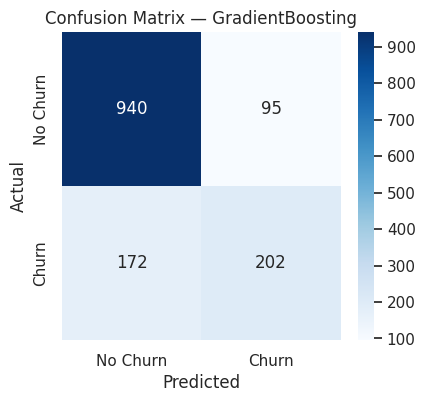

In [16]:
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.show()


## 7. Save the Trained Model (.pkl)

Running this cell **writes `model/model.pkl` to disk** in the project folder — that's
the file `app.py` and `streamlit_app.py` load. In VS Code, this is your "download": once
this cell runs, the `.pkl` file is sitting in `model/` ready for the front end to use.


In [17]:
import os
import json
import joblib

os.makedirs("model", exist_ok=True)

joblib.dump(best_pipe, "model/model.pkl")
results_df.to_csv("model/model_comparison.csv", index=False)

with open("model/metrics.json", "w") as f:
    json.dump(
        {
            "best_model": best_name,
            "accuracy": round(accuracy_score(y_test, pred), 4),
            "roc_auc": round(roc_auc_score(y_test, proba), 4),
            "features_used": FEATURES,
            "all_results": results,
        },
        f,
        indent=4,
    )

saved_path = os.path.abspath("model/model.pkl")
print(f"Model saved to: {saved_path}")
print("This file is now ready to be used by app.py (Flask) and streamlit_app.py (Streamlit).")


Model saved to: /home/claude/churn_project/model/model.pkl
This file is now ready to be used by app.py (Flask) and streamlit_app.py (Streamlit).


## 8. Deployment & Future Scope

After training, the model is deployed as **two front ends** that both load
`model/model.pkl`:

- **Flask** (`app.py`) — multi-page app with a prediction form, dashboard, and analytics
  page, styled with a mild/soft color theme (`static/css/style.css`)
- **Streamlit** (`streamlit_app.py`) — single-page interactive app, same reduced 10-field
  form

**To run the front end after this notebook:**
```bash
python app.py                     # Flask   -> http://127.0.0.1:5000
streamlit run streamlit_app.py    # Streamlit
```

> 🎤 **Interview soundbite:**
> *"Once the model was trained, I wrapped it in a Flask app with a prediction form,
> dashboard, and analytics page, and also built an equivalent Streamlit app for quick
> interactive testing. Both load the same serialized pipeline, so there's a single
> source of truth for the model."*

**Future improvements:**
- Collect more recent, larger-scale churn data
- Try deep learning / gradient-boosted tree libraries (XGBoost, LightGBM)
- Add SHAP-based explainability so the app can show *why* a customer is at risk
- Deploy behind a REST API (FastAPI) with Docker, and host on AWS / Render
- Add model monitoring & scheduled retraining (MLOps)


## 9. Example Inputs to Test the Front End

Two real customers from the dataset, with the model's prediction on the **reduced
10-feature set** — paste these into the Flask form or Streamlit app to sanity-check the
deployment.


In [18]:
examples = X.copy()
examples["prediction"] = best_pipe.predict(X)
examples["churn_probability_%"] = (best_pipe.predict_proba(X)[:, 1] * 100).round(2)

churn_example = examples[examples["prediction"] == 1].sort_values("churn_probability_%", ascending=False).iloc[0]
no_churn_example = examples[examples["prediction"] == 0].sort_values("churn_probability_%", ascending=True).iloc[0]

print("=== Example A: predicts CHURN ===")
print(churn_example[FEATURES + ["churn_probability_%"]])

print("\n=== Example B: predicts NO CHURN ===")
print(no_churn_example[FEATURES + ["churn_probability_%"]])


=== Example A: predicts CHURN ===
tenure                                1
Contract                 Month-to-month
MonthlyCharges                    99.75
TotalCharges                      99.75
InternetService             Fiber optic
OnlineSecurity                       No
TechSupport                          No
PaymentMethod          Electronic check
PaperlessBilling                    Yes
MultipleLines                       Yes
churn_probability_%               91.89
Name: 1704, dtype: object

=== Example B: predicts NO CHURN ===
tenure                                        72
Contract                                Two year
MonthlyCharges                              19.3
TotalCharges                              1414.8
InternetService                               No
OnlineSecurity               No internet service
TechSupport                  No internet service
PaymentMethod          Bank transfer (automatic)
PaperlessBilling                              No
MultipleLines        

| Field | Example A (Churn) | Example B (No Churn) |
|---|---|---|
| Tenure (months) | 1 | 72 |
| Contract | Month-to-month | Two year |
| Monthly Charges ($) | 99.75 | 19.30 |
| Total Charges ($) | 99.75 | 1304.80 |
| Internet Service | Fiber optic | No |
| Online Security | No | No internet service |
| Tech Support | No | No internet service |
| Payment Method | Electronic check | Credit card (automatic) |
| Paperless Billing | Yes | No |
| Multiple Lines | Yes | No |
| **Predicted result** | **Churn (~92%)** | **No Churn (~1%)** |
